In [1]:
%pip install pandas scikit-learn nltk openpyxl

import os
import re
import string
import numpy as np
import pandas as pd
import nltk


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import TruncatedSVD  
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline  
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 

Note: you may need to restart the kernel to use updated packages.


In [2]:
# MBTI dataset (CSV)
mbti = pd.read_csv("myer-briggs-data.csv")
mbti.columns = ["type", "post"]
mbti


,type,post
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...
...,...,...
8670,ISFP,'https://www.youtube.com/watch?v=t8edHB_h908||...
8671,ENFP,'So...if this thread already exists someplace ...
8672,INTP,'So many questions when i do these things. I ...
8673,INFP,'I am very conflicted right now when it comes ...


In [3]:
#extroverted dataset
extroverted = pd.read_csv("dataset/extroverted.csv", header=None, engine="python")
extroverted.columns = ["type"] + ["post"] * (extroverted.shape[1] - 1)
extroverted = extroverted.replace(r"^[\s/]+$", "NaN", regex=True)

test_set = extroverted[extroverted["type"] == "<UNKNOWN>"].copy()
# remove those rows from the extroverted dataset
extroverted = extroverted[extroverted["type"] != "<UNKNOWN>"].copy()

extroverted = extroverted.dropna(axis=1, how='all')

extroverted


,type,post,post,post,post,post,post,post,post,post,...,post,post,post,post,post,post,post,post,post,post
0,ENTJ,"QQQ Mailbox CV: Don't get mad, you know at lea...",Tura,I'm taking you away. Up above the marshes,above the valleys,over the mountains and the forest,over the clouds and the sea,over the sun,over the clouds,over the limits of the world of stars,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ESTP,# To marry Zhong Han Liang #|||Zhong Han Liang...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ISFJ,"However, the wood belt / / @Green Bean Fries: ...",and I've always reported my phone number: 13**,***,****. Get used to it|||Thank you. It's like twit,too? Take care of yourself! Be safe! Be carefu...,Tsinjin Fire Command: The explosives are mainl...,mourn|||# Happy birthday to Fedler # # Happy b...,Fredler|||Happy birthday to Fedler|||[Poor] / ...,by the way|||Loandy knows best,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,INFJ,Ha|||Ha-ha-ha-ha-ha|||@RubyDedidi:Repost|||# h...,innocent boy's walls,hectic president's beverage,/ / star's red sugar,warm man's I. / / / / / / / / / / / / / / / / ...,but why not..|||||||||MY FRIEND IS A FOOL: HE ...,NOT ONLY IS HE SUPERIOR,BUT HE MUST BE PATIENT. YOU GUYS DID IT. I'LL ...,sad..|||It's so warm|||Aren't you my monk|||||...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ISTP,I don't know if there's any yogurt|||Once almo...,slow down|||#MILLION LOVE WEILAND # THE CONTIN...,and now it's the New Wave,and it's full fire,and it's going to be fun for you. You,you,you,you,you're all down! 26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,ENFJ,|||[crying] keep your heart on the back of you...,and you'll get a little secret from me. @shard...,YOU DROPPED YOUR SOAP|||吖/[Turn] shared Slash ...,whose guitar is here... http://t.cn/8kwQexH|||...,the more you get to drink,the more you get to work,the more you get to walk by yourself... Is the...,"template free of charge # I'm using the ""Rolly...",wave face. Watch the video and learn more! htt...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,ENFJ,"|||Leave your footprints, say something. Let m...",the sky goes down,there's nothing going on. =|||||||||I don't wa...,the binary sails for the dream of a homemade a...,corrected by elderman == == sync,corrected by elderman == @elder_man|||It's a r...,and it's time for me to sleep. I'm not done wi...,but the problem has to be solved. I've been lo...,but there's more than an 8 level behind it. =|...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,ISFJ,"toming #beautiful life""|||[Haha]|||SOMETIMES I...",AND THE WORLD MUST BE WRONG|||#http://t.cn/RGO...,and I smiled at the screen,and I kept the girl away|||#bilibili# [Hinesh ...,but the twat buys them to satisfy [thinking] /...,but not for the love of you|||new year's wish:...,ta knows that it hurts when you practice it|||...,but I'm like a balloon,and I don't have the power to study anymore|||...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,ISTJ,@DINDING AND THE MINI-WOW CONCERTS WERE CALLED...,aah,"aah!"" This is my last chance! @StafCetaphil Xiaof",please [Cry tears] [Cry tears] [Cry tears] [Cr...,and I waited a year to see him [Cry tears] [Cr...,please [Cry tears] [Cry tears] [Cry tears] [Cr...,and I waited a year to see him [Cry tears] [Cr...,ah,ah! This is my last chance! @StafCetaphil Xiaof,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# melt all post columns into one column named "post"
# rename ALL post columns to unique names.
post_cols = [col for col in extroverted.columns if col != "type"]
extroverted = extroverted.rename(
    columns={col: f"post_{i}" for i, col in enumerate(post_cols)}
)

# melt 
long_extroverted = extroverted.melt(
    id_vars=["type"],
    value_vars=[col for col in extroverted.columns if col.startswith("post_")],
    var_name="post_number",
    value_name="post"
)

# clean up
long_extroverted = long_extroverted.dropna(subset=["post"])
long_extroverted = long_extroverted[long_extroverted["post"] != ""]
long_extroverted = long_extroverted.reset_index(drop=True)
long_extroverted = long_extroverted.drop(columns=["post_number"])

long_extroverted

,type,post
0,ENTJ,"QQQ Mailbox CV: Don't get mad, you know at lea..."
1,ESTP,# To marry Zhong Han Liang #|||Zhong Han Liang...
2,ISFJ,"However, the wood belt / / @Green Bean Fries: ..."
3,INFJ,Ha|||Ha-ha-ha-ha-ha|||@RubyDedidi:Repost|||# h...
4,ISTP,I don't know if there's any yogurt|||Once almo...
...,...,...
81420,INFJ,SKYCATS ACCOUNT FOR 53.3 PER CENT
81421,INFJ,KYOTO|||In the middle of the night
81422,INFJ,who else would want to die of poverty in the v...
81423,INFJ,Ha ha! Is that a quick turn of mind or somethi...


In [5]:
mbti = pd.concat([mbti, long_extroverted], ignore_index=True)
mbti.to_csv("updated_mbti.csv", index=False)

In [6]:
mbti = mbti[mbti["post"].notna() & (mbti["post"].str.strip() != "") & (mbti["post"].str.strip() != "NaN")]
#nan_mbti = mbti["post"].isna().sum()
#nan_mbti

In [7]:
mbti.shape

(87084, 2)

In [8]:
###TASK 1: Dataset Inspection###
#inspecting the datasets
def inspect_dataset(df,name="Dataset"):
  print(f"/n====={name} INSPECTION=====")

  print(f"Shape: {df.shape}")
  print(f"Columns: {df.columns}")
  print("Info:")
  print(df.info())

  print("\nHead:")
  print(df.head())
  print("\nMissing Values per Column:")
  print(df.isnull().sum())

  print("\nSummary Statistics:(numeric columns):")
  print(df.describe())

inspect_dataset(mbti, "MBTI Dataset")

###TASK 2: Standardization Diagnostics:###
# Align Column Names
def standardize_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

mbti = standardize_columns(mbti)

/n=====MBTI Dataset INSPECTION=====
Shape: (87084, 2)
Columns: Index(['type', 'post'], dtype='object')
Info:
<class 'pandas.core.frame.DataFrame'>
Index: 87084 entries, 0 to 90099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    87084 non-null  object
 1   post    87084 non-null  object
dtypes: object(2)
memory usage: 2.0+ MB
None

Head:
   type                                               post
0  INFJ  'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1  ENTP  'I'm finding the lack of me in these posts ver...
2  INTP  'Good one  _____   https://www.youtube.com/wat...
3  INTJ  'Dear INTP,   I enjoyed our conversation the o...
4  ENTJ  'You're fired.|||That's another silly misconce...

Missing Values per Column:
type    0
post    0
dtype: int64

Summary Statistics:(numeric columns):
         type   post
count   87084  87084
unique     16  78228
top      INFJ     ha
freq    28179    710


In [10]:
### TASK 3: Clean data, remove stopwords and tokenize text ###


# Prepare stop words (combine sklearn's stop words with NLTK's if available)
stop_words = set(ENGLISH_STOP_WORDS)
try:
    from nltk.corpus import stopwords as nltk_stop
    stop_words = stop_words.union(set(nltk_stop.words('english')))
except Exception:
    # NLTK stopwords may not be downloaded in this environment; it's ok to proceed
    pass

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

mbti['cleaned_text'] = mbti.get('post', '') .apply(clean_text) if 'post' in mbti.columns else ''
mbti["cleaned_text"] = mbti["post"].apply(clean_text)

#vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5)
vectorizer = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1,3), 
    min_df=3
)
X = vectorizer.fit_transform(mbti["cleaned_text"])
y = mbti["type"] if "type" in mbti.columns else None

In [11]:
### Task 2A-Prep: Encode MBTI Labels ###


# One-Hot Encoding for 16 MBTI types
try:
    # sklearn >= 1.2 uses 'sparse_output'
    from sklearn.preprocessing import OneHotEncoder
    OHE_KW = dict(sparse_output=False, handle_unknown='ignore')

    _ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:

    from sklearn.preprocessing import OneHotEncoder
    OHE_KW = dict(sparse=False, handle_unknown='ignore')

if 'type' not in mbti.columns:
    raise ValueError("Expected a 'type' column in the MBTI dataset.")

# Fit & transform
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe = encoder.fit_transform(mbti[['type']])

# Build DF with aligned index
ohe_df = pd.DataFrame(
    ohe,
    columns=encoder.get_feature_names_out(['type']),
    index=mbti.index
)

# Merge back
mbti_ohe = pd.concat([mbti, ohe_df], axis=1)

# Binary Axes (I/E, N/S, T/F, J/P)
def split_axes(mbti_type: str):
    t = str(mbti_type).upper()
    if len(t) != 4:
        return pd.Series([np.nan, np.nan, np.nan, np.nan], index=["IE","NS","TF","JP"])
    return pd.Series([t[0], t[1], t[2], t[3]], index=["IE","NS","TF","JP"])

axes = mbti_ohe['type'].apply(split_axes)

label_maps = {
    "IE": {"I": 1, "E": 0},
    "NS": {"N": 1, "S": 0},
    "TF": {"T": 1, "F": 0},
    "JP": {"J": 1, "P": 0},
}

for col, mapping in label_maps.items():
    axes[col + "_y"] = axes[col].map(mapping)

# Combine with the MBTI one-hot dataset
mbti_encoded = pd.concat([mbti_ohe, axes], axis=1)

In [12]:
clf_16 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5)),
    ("svd", TruncatedSVD(n_components=200)),
    ("logreg", LogisticRegression(max_iter=3000))
])

scores_16 = cross_val_score(clf_16, mbti["cleaned_text"], mbti["type"], cv=5)
print("16-class accuracy:", scores_16.mean())

axes_cols = ["IE_y", "NS_y", "TF_y", "JP_y"]

for col in axes_cols:
    clf = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5)),
        ("svd", TruncatedSVD(n_components=200)),
        ("logreg", LogisticRegression(max_iter=3000)),
    ])

    y = mbti_encoded[col].squeeze().astype(int)  # ensures 1D and integer type
    # ensure it's a 1D array
    scores = cross_val_score(
        clf,
        mbti_encoded["cleaned_text"],
        y,
        cv=5
    )
    
    print(f"{col} accuracy: {scores.mean():.4f}")

16-class accuracy: 0.34237059479345955
IE_y accuracy: 0.7845
NS_y accuracy: 0.5737
TF_y accuracy: 0.7601
JP_y accuracy: 0.7773


In [13]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        min_df=3
    )),
    ("svm", LinearSVC(class_weight="balanced"))
])

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        min_df=3
    )),
    ("svm", LinearSVC(class_weight="balanced"))
])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mbti["cleaned_text"], 
    mbti["type"],
    test_size=0.2,
    random_state=42,
    stratify=mbti["type"]
)

clf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred)


Test accuracy: 0.34868232186943793


In [14]:
# MBTI axis pipeline: train 4 binary models, save them, predict a 4-letter type
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

# ensure axis labels exist
if 'mbti_encoded' not in globals():
    mbti_encoded = mbti.copy()  # assumes `mbti` exists with 'type' and 'cleaned_text'

if 'cleaned_text' not in mbti_encoded.columns and 'post' in mbti_encoded.columns:
    mbti_encoded['cleaned_text'] = mbti_encoded['post'].fillna('').apply(clean_text)

# create axis columns if missing
if not {'IE_y','NS_y','TF_y','JP_y'}.issubset(set(mbti_encoded.columns)):
    def split_axes(t):
        t = str(t).upper()[:4]
        if len(t) != 4:
            return pd.Series([np.nan,np.nan,np.nan,np.nan], index=['IE','NS','TF','JP'])
        return pd.Series(list(t), index=['IE','NS','TF','JP'])
    axes = mbti_encoded['type'].apply(split_axes)
    mapping = {'I':1, 'E':0, 'N':1, 'S':0, 'T':1, 'F':0, 'J':1, 'P':0}
    for col in ['IE','NS','TF','JP']:
        mbti_encoded[col + '_y'] = axes[col].map(mapping)

# Features: Word + Char TF-IDF
word_tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    min_df=3,
    sublinear_tf=True
)

features = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

# Train/Test split
# Stratify on the 16-class 'type' so the test set represents all MBTI types
X = mbti_encoded['cleaned_text'].fillna('').values
y16 = mbti_encoded['type'].values

X_train, X_test, y16_train, y16_test, idx_train, idx_test = train_test_split(
    X, y16, mbti_encoded.index,
    test_size=0.20, stratify=y16, random_state=42
)

# training index arrays to lookup axis labels in mbti_encoded
train_idx = idx_train
test_idx = idx_test

# Helper to build pipeline per classifier type
def build_axis_pipeline(clf_type='svm', C=1.0):
    """
    clf_type: 'svm' or 'logreg'
    returns sklearn Pipeline with features + classifier
    """
    if clf_type == 'svm':
        # LinearSVC usually works best in high-dim TFIDF; calibrate it for probabilities if needed
        base = LinearSVC(C=C, class_weight='balanced', max_iter=20000)
        clf = CalibratedClassifierCV(base, cv=3)  # gives predict_proba
    elif clf_type == 'logreg':
        clf = LogisticRegression(C=C, solver='saga', class_weight='balanced', max_iter=20000)
    else:
        raise ValueError("clf_type must be 'svm' or 'logreg'")
    pipe = Pipeline([
        ('features', features),
        ('clf', clf)
    ])
    return pipe

# Train one model per axis
axes = ['IE_y','NS_y','TF_y','JP_y']
axis_models = {}
axis_cv = {}
clf_choice = 'svm'   
C = 1.0              
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for axis in axes:
    y_train_axis = mbti_encoded.loc[train_idx, axis].astype(int).values
    pipe = build_axis_pipeline(clf_type=clf_choice, C=C)
    #  cross-val to estimate axis performance (on train set)
    scores = cross_val_score(pipe, X_train, y_train_axis, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"{axis} CV (train) accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    axis_cv[axis] = scores
    # fit on entire train set
    pipe.fit(X_train, y_train_axis)
    axis_models[axis] = pipe
    # save model
    os.makedirs('mbti_axis_models', exist_ok=True)
    joblib.dump(pipe, f'mbti_axis_models/{axis}_{clf_choice}.joblib')

# Evaluate on held-out test set
y_pred_axes_test = {}
axis_test_reports = {}
for axis, model in axis_models.items():
    y_true = mbti_encoded.loc[test_idx, axis].astype(int).values
    y_pred = model.predict(X_test)
    y_pred_axes_test[axis] = y_pred
    print(f"\n=== {axis} test report ===")
    print(classification_report(y_true, y_pred, digits=4))
    axis_test_reports[axis] = classification_report(y_true, y_pred, digits=4, output_dict=True)

# Combine per-axis predictions to get 4-letter MBTI
def axis_value_to_letter(axis_name, val):
    if axis_name == 'IE_y':
        return 'I' if val==1 else 'E'
    if axis_name == 'NS_y':
        return 'N' if val==1 else 'S'
    if axis_name == 'TF_y':
        return 'T' if val==1 else 'F'
    if axis_name == 'JP_y':
        return 'J' if val==1 else 'P'
    raise ValueError(axis_name)

def combine_axes_dict(preds_dict):
    """preds_dict: {'IE_y': array([...]), ...} -> np.array of 4-letter types"""
    n = len(next(iter(preds_dict.values())))
    out = []
    for i in range(n):
        letters = [axis_value_to_letter(a, preds_dict[a][i]) for a in ['IE_y','NS_y','TF_y','JP_y']]
        out.append(''.join(letters))
    return np.array(out)

# Reconstructed MBTI on the test set
y16_reconstructed_test = combine_axes_dict(y_pred_axes_test)
y16_true_test = mbti_encoded.loc[test_idx, 'type'].values
recon_acc = accuracy_score(y16_true_test, y16_reconstructed_test)
print(f"\nReconstructed 16-class accuracy (from 4 binary models) on test set: {recon_acc:.4f}")

def predict_mbti(post_text, model_dir='mbti_axis_models', clf_type=clf_choice):
    """
    Input: raw post text (string)
    Output: dict with axis predictions, probabilities, and combined MBTI string
    """
    txt = clean_text(post_text) if 'clean_text' in globals() else str(post_text).lower()
    # load models if not in memory
    preds = {}
    probs = {}
    for axis in axes:
        model_path = os.path.join(model_dir, f'{axis}_{clf_type}.joblib')
        if axis in axis_models:
            model = axis_models[axis]
        elif os.path.exists(model_path):
            model = joblib.load(model_path)
        else:
            raise FileNotFoundError(f"Model for {axis} not found at {model_path}")
        
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba([txt])[0]
            # assume positive class (1) is second column if classes are [0,1]
            p_pos = proba[list(model.classes_).index(1)] if 1 in model.classes_ else proba[-1]
        else:
            # fallback: CalibratedClassifierCV or classifiers without predict_proba
            try:
                p_pos = model.predict_proba([txt])[0][1]
            except Exception:
                # no prob available; use decision function and sigmoid mapping as fallback (less calibrated)
                if hasattr(model, "decision_function"):
                    score = model.decision_function([txt])[0]
                    # minimal sigmoid
                    p_pos = 1 / (1 + np.exp(-score))
                else:
                    p_pos = None
        pred = int(model.predict([txt])[0])
        preds[axis] = pred
        probs[axis] = p_pos
    combined = combine_axes_dict(preds)
    return {
        'IE': ('I' if preds['IE_y']==1 else 'E'),
        'NS': ('N' if preds['NS_y']==1 else 'S'),
        'TF': ('T' if preds['TF_y']==1 else 'F'),
        'JP': ('J' if preds['JP_y']==1 else 'P'),
        'probs': probs,
        'mbti': combined[0]
    }

# Example usage:
example_post = "I love quiet nights with a good book and deep conversations about theories."
print("\nPrediction example:", predict_mbti(example_post))

Exception ignored in: <function ResourceTracker.__del__ at 0x104fd9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107d7dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1074fdbc0>
Traceback (most recent call last

IE_y CV (train) accuracy: 0.8076 ± 0.0012


Exception ignored in: <function ResourceTracker.__del__ at 0x102fb5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1052a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106d8dbc0>
Traceback (most recent call last

NS_y CV (train) accuracy: 0.6622 ± 0.0025


Exception ignored in: <function ResourceTracker.__del__ at 0x104bd9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104e0dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107ed1bc0>
Traceback (most recent call last

TF_y CV (train) accuracy: 0.8151 ± 0.0020


Exception ignored in: <function ResourceTracker.__del__ at 0x104e39bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105b25bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105461bc0>
Traceback (most recent call last

JP_y CV (train) accuracy: 0.8051 ± 0.0027

=== IE_y test report ===
              precision    recall  f1-score   support

           0     0.8216    0.1459    0.2478      3756
           1     0.8085    0.9913    0.8906     13661

    accuracy                         0.8090     17417
   macro avg     0.8150    0.5686    0.5692     17417
weighted avg     0.8113    0.8090    0.7520     17417


=== NS_y test report ===
              precision    recall  f1-score   support

           0     0.6357    0.4258    0.5100      7142
           1     0.6754    0.8304    0.7449     10275

    accuracy                         0.6645     17417
   macro avg     0.6555    0.6281    0.6274     17417
weighted avg     0.6591    0.6645    0.6486     17417


=== TF_y test report ===
              precision    recall  f1-score   support

           0     0.8224    0.9721    0.8910     13186
           1     0.7989    0.3455    0.4824      4231

    accuracy                         0.8199     17417
   macro

TypeError: object of type 'int' has no len()

In [20]:
import pandas as pd

comparison_data = []

# --- 16-class baseline ---
comparison_data.append({
    "Model": "LogReg + SVD (16-class CV)",
    "Task": "16-type",
    "Accuracy": scores_16.mean()
})

comparison_data.append({
    "Model": "Linear SVM (16-class test)",
    "Task": "16-type",
    "Accuracy": accuracy_score(y_test, y_pred)
})

comparison_data.append({
    "Model": "Reconstructed from 4 Axes",
    "Task": "16-type",
    "Accuracy": recon_acc
})

# --- Axis results from earlier CV ---
comparison_data.append({"Model":"LogReg + SVD", "Task":"IE", "Accuracy":0.7845})
comparison_data.append({"Model":"LogReg + SVD", "Task":"NS", "Accuracy":0.5737})
comparison_data.append({"Model":"LogReg + SVD", "Task":"TF", "Accuracy":0.7601})
comparison_data.append({"Model":"LogReg + SVD", "Task":"JP", "Accuracy":0.7773})

# --- Axis results from improved Word+Char+SVM ---
for axis in axis_test_reports:
    acc = axis_test_reports[axis]["accuracy"]
    comparison_data.append({
        "Model":"Word+Char TFIDF + SVM",
        "Task":axis,
        "Accuracy":acc
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by="Accuracy", ascending=False)
comparison_df


,Model,Task,Accuracy
9,Word+Char TFIDF + SVM,TF_y,0.819889
10,Word+Char TFIDF + SVM,JP_y,0.809382
7,Word+Char TFIDF + SVM,IE_y,0.808980
3,LogReg + SVD,IE,0.784500
6,LogReg + SVD,JP,0.777300
5,LogReg + SVD,TF,0.760100
8,Word+Char TFIDF + SVM,NS_y,0.664466
4,LogReg + SVD,NS,0.573700
2,Reconstructed from 4 Axes,16-type,0.411380
0,LogReg + SVD (16-class CV),16-type,0.342371


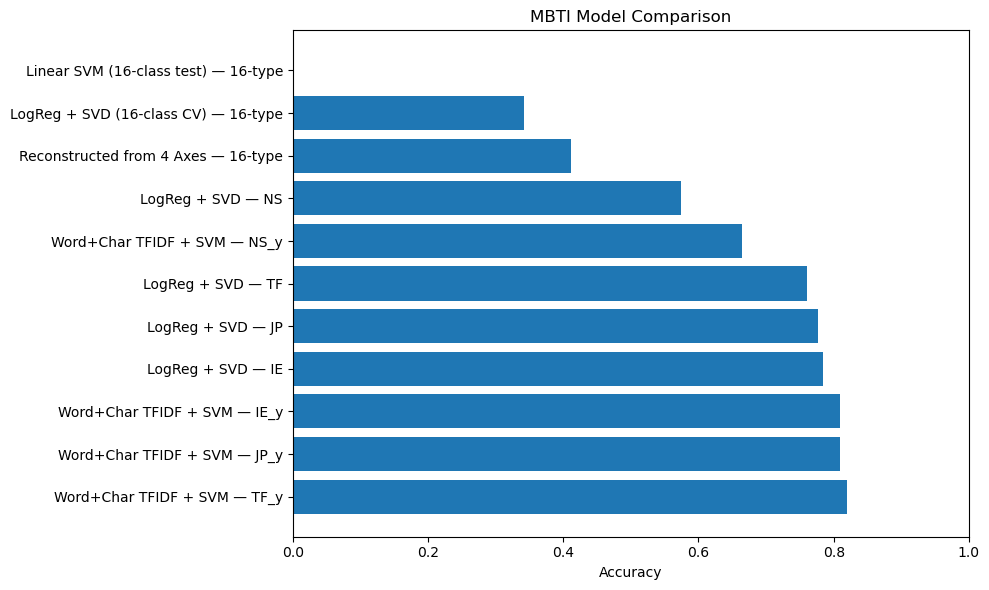

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(comparison_df["Model"] + " — " + comparison_df["Task"], comparison_df["Accuracy"])
plt.xlabel("Accuracy")
plt.title("MBTI Model Comparison")
plt.xlim(0,1)
plt.tight_layout()
plt.show()


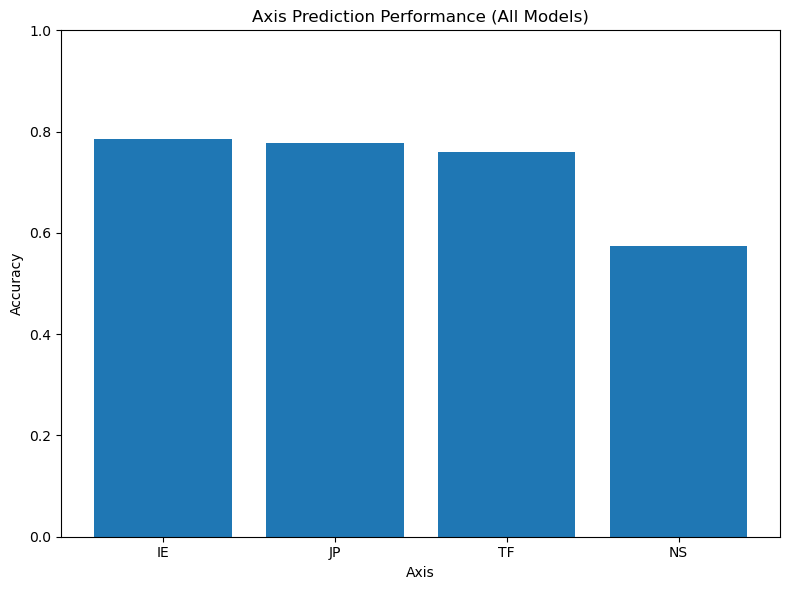

In [22]:
axis_comparison = comparison_df[comparison_df["Task"].isin(["IE","NS","TF","JP"])]

plt.figure(figsize=(8,6))
plt.bar(axis_comparison["Task"], axis_comparison["Accuracy"])
plt.xlabel("Axis")
plt.ylabel("Accuracy")
plt.title("Axis Prediction Performance (All Models)")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
